# DeepLense — Test V: Lens Finding & Data Pipelines
**GSOC 2026 | ML4Sci / DeepLense**

Binary classification: strong gravitational lens vs non-lens, using PyTorch.

## 1. Setup

In [1]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.transforms import functional as TF

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

USE_AMP = DEVICE.type == 'cuda'  # GradScaler not supported on MPS

print(f'Device: {DEVICE} | AMP: {USE_AMP}')

Device: mps | AMP: False


/Users/angshumansmac/Desktop/BTECH/Sem6/GSOC/Test/Test-II/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Adjust if dataset is elsewhere
DATA_ROOT = 'lens-finding-test'

TRAIN_LENSES    = os.path.join(DATA_ROOT, 'train_lenses')
TRAIN_NONLENSES = os.path.join(DATA_ROOT, 'train_nonlenses')
TEST_LENSES     = os.path.join(DATA_ROOT, 'test_lenses')
TEST_NONLENSES  = os.path.join(DATA_ROOT, 'test_nonlenses')

## 2. Dataset Exploration

In [3]:
train_lens_files    = sorted(glob.glob(os.path.join(TRAIN_LENSES,    '*.npy')))
train_nonlens_files = sorted(glob.glob(os.path.join(TRAIN_NONLENSES, '*.npy')))
test_lens_files     = sorted(glob.glob(os.path.join(TEST_LENSES,     '*.npy')))
test_nonlens_files  = sorted(glob.glob(os.path.join(TEST_NONLENSES,  '*.npy')))

print(f'Train  — lenses: {len(train_lens_files):>6,}  |  non-lenses: {len(train_nonlens_files):>6,}  |  ratio 1:{len(train_nonlens_files)//len(train_lens_files)}')
print(f'Test   — lenses: {len(test_lens_files):>6,}  |  non-lenses: {len(test_nonlens_files):>6,}  |  ratio 1:{len(test_nonlens_files)//len(test_lens_files)}')

sample = np.load(train_lens_files[0])
print(f'\nArray shape: {sample.shape}, dtype: {sample.dtype}, range: [{sample.min():.3f}, {sample.max():.3f}]')

Train  — lenses:  1,730  |  non-lenses: 28,675  |  ratio 1:16
Test   — lenses:    195  |  non-lenses: 19,455  |  ratio 1:99

Array shape: (3, 64, 64), dtype: float32, range: [0.000, 1.000]


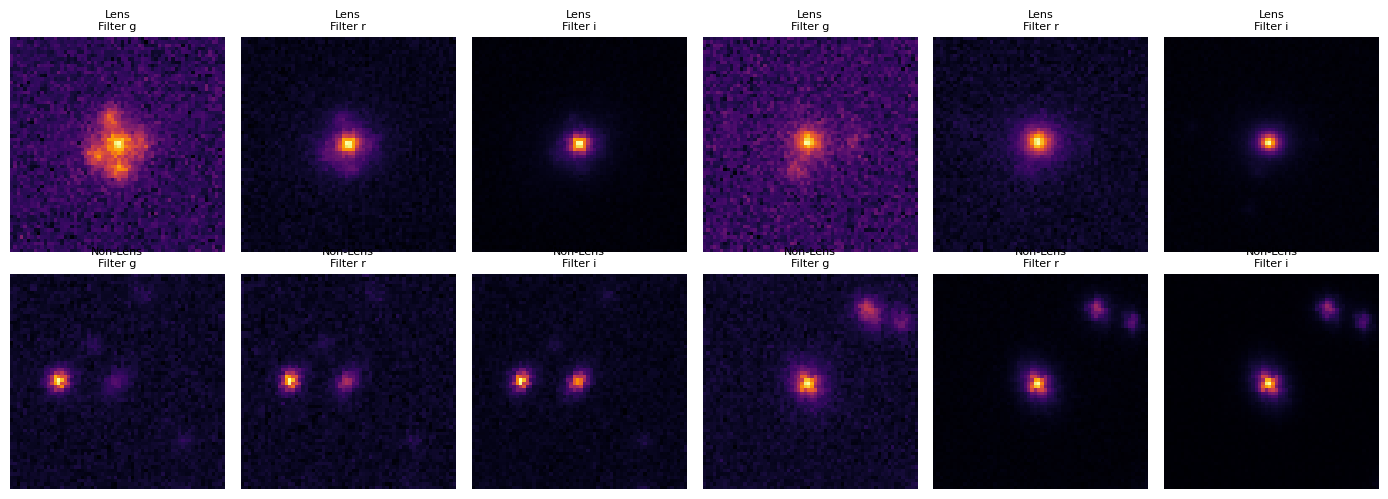

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
filter_names = ['Filter g', 'Filter r', 'Filter i']

lens_samples    = [np.load(f) for f in random.sample(train_lens_files, 2)]
nonlens_samples = [np.load(f) for f in random.sample(train_nonlens_files, 2)]

for row_idx, (samples, label) in enumerate([(lens_samples, 'Lens'), (nonlens_samples, 'Non-Lens')]):
    for col_idx, img in enumerate(samples):
        for ch in range(3):
            ax = axes[row_idx][col_idx * 3 + ch]
            ax.imshow(img[ch], cmap='inferno', origin='lower')
            ax.set_title(f'{label}\n{filter_names[ch]}', fontsize=8)
            ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Dataset Class

In [5]:
class LensDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img = torch.from_numpy(np.load(self.file_paths[idx]).astype(np.float32))  # (3, 64, 64)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.float32)

## 4. Normalization & Augmentation

In [6]:
# Compute per-channel mean/std from training set
print('Computing normalization stats (this takes ~30s)...')
all_train_files = train_lens_files + train_nonlens_files

# Reservoir sampling to keep memory bounded
sample_files = random.sample(all_train_files, min(3000, len(all_train_files)))
stack = np.stack([np.load(f).astype(np.float32) for f in sample_files])  # (N, 3, 64, 64)

MEAN = stack.mean(axis=(0, 2, 3))
STD  = stack.std(axis=(0, 2, 3))
print(f'Mean: {MEAN}\nStd:  {STD}')

Computing normalization stats (this takes ~30s)...
Mean: [0.277688   0.19269313 0.10449755]
Std:  [0.17299376 0.1535041  0.11187008]


In [7]:
class PerChannelNormalize(object):
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean).view(3, 1, 1)
        self.std  = torch.tensor(std).view(3, 1, 1)

    def __call__(self, x):
        return (x - self.mean) / (self.std + 1e-8)


class AddGaussianNoise(object):
    def __init__(self, sigma=0.01):
        self.sigma = sigma

    def __call__(self, x):
        return x + torch.randn_like(x) * self.sigma


# Full rotation (0-360) + flips — lenses have no preferred orientation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=180),
    AddGaussianNoise(sigma=0.01),
    PerChannelNormalize(MEAN, STD),
])

val_transform = transforms.Compose([
    PerChannelNormalize(MEAN, STD),
])

## 5. Train/Val Split & DataLoaders

90:10 split of training data, stratified to preserve class ratio.

In [8]:
all_files  = train_lens_files + train_nonlens_files
all_labels = [1] * len(train_lens_files) + [0] * len(train_nonlens_files)

train_files, val_files, train_labels, val_labels = train_test_split(
    all_files, all_labels,
    test_size=0.10,
    stratify=all_labels,
    random_state=SEED
)

print(f'Train: {sum(train_labels)} lenses / {train_labels.count(0)} non-lenses')
print(f'Val:   {sum(val_labels)} lenses / {val_labels.count(0)} non-lenses')

Train: 1557 lenses / 25807 non-lenses
Val:   173 lenses / 2868 non-lenses


In [9]:
train_dataset = LensDataset(train_files, train_labels, transform=train_transform)
val_dataset   = LensDataset(val_files,   val_labels,   transform=val_transform)

test_files  = test_lens_files + test_nonlens_files
test_labels = [1] * len(test_lens_files) + [0] * len(test_nonlens_files)
test_dataset = LensDataset(test_files, test_labels, transform=val_transform)

# WeightedRandomSampler — oversample lenses so each batch sees ~50% lenses
class_counts = [train_labels.count(0), train_labels.count(1)]
sample_weights = [1.0 / class_counts[lbl] for lbl in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 64
PIN = DEVICE.type == 'cuda'  # pin_memory only helps on CUDA

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=PIN)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=0, pin_memory=PIN)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=0, pin_memory=PIN)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Train batches: 428 | Val batches: 48 | Test batches: 308


## 6. Model

ResNet18 pretrained on ImageNet. 64×64 × 3-channel input works without modification — I only replace the final FC.

In [10]:
def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model.to(DEVICE)

model = build_model()
total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')

Parameters: 11,177,025


## 7. Focal Loss

Chosen over weighted BCE because of the extreme test-set skew (1:100). Focal Loss down-weights easy negatives dynamically rather than using a fixed weight.

In [11]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt  = torch.exp(-bce)
        at  = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (at * (1 - pt) ** self.gamma * bce).mean()

## 8. Training

In [12]:
from sklearn.metrics import roc_auc_score

EPOCHS   = 50
LR       = 1e-3
PATIENCE = 10

criterion = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler    = torch.cuda.amp.GradScaler(enabled=USE_AMP)


def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, all_probs, all_targets = 0.0, [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, targets in loader:
            imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
            with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
                logits = model(imgs).squeeze(1)
                loss   = criterion(logits, targets)

            if training:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss  += loss.item() * len(targets)
            all_probs.extend(torch.sigmoid(logits).cpu().detach().numpy())
            all_targets.extend(targets.cpu().numpy())

    avg_loss  = total_loss / len(loader.dataset)
    auc_score = roc_auc_score(all_targets, all_probs)
    return avg_loss, auc_score


best_val_auc = 0.0
patience_ctr = 0
history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_auc = run_epoch(train_loader, training=True)
    val_loss,   val_auc   = run_epoch(val_loader,   training=False)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f}  AUC: {train_auc:.4f} | '
          f'Val   Loss: {val_loss:.4f}  AUC: {val_auc:.4f}')

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_ctr = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'\nBest Val AUC: {best_val_auc:.4f}')

/var/folders/b4/3y3n_8dd2vv1690lzd30n7d80000gn/T/ipykernel_52886/1456464347.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Epoch 01/50 | Train Loss: 0.0304  AUC: 0.9643 | Val   Loss: 0.0232  AUC: 0.9802
Epoch 02/50 | Train Loss: 0.0198  AUC: 0.9820 | Val   Loss: 0.0212  AUC: 0.9844
Epoch 03/50 | Train Loss: 0.0161  AUC: 0.9880 | Val   Loss: 0.0144  AUC: 0.9818
Epoch 04/50 | Train Loss: 0.0150  AUC: 0.9896 | Val   Loss: 0.0106  AUC: 0.9870
Epoch 05/50 | Train Loss: 0.0182  AUC: 0.9850 | Val   Loss: 0.0230  AUC: 0.9863
Epoch 06/50 | Train Loss: 0.0178  AUC: 0.9861 | Val   Loss: 0.0194  AUC: 0.9833
Epoch 07/50 | Train Loss: 0.0160  AUC: 0.9882 | Val   Loss: 0.0240  AUC: 0.9873
Epoch 08/50 | Train Loss: 0.0132  AUC: 0.9919 | Val   Loss: 0.0261  AUC: 0.9872
Epoch 09/50 | Train Loss: 0.0124  AUC: 0.9929 | Val   Loss: 0.0194  AUC: 0.9863
Epoch 10/50 | Train Loss: 0.0123  AUC: 0.9930 | Val   Loss: 0.0132  AUC: 0.9908
Epoch 11/50 | Train Loss: 0.0116  AUC: 0.9936 | Val   Loss: 0.0100  AUC: 0.9891
Epoch 12/50 | Train Loss: 0.0108  AUC: 0.9946 | Val   Loss: 0.0125  AUC: 0.9904
Epoch 13/50 | Train Loss: 0.0110  AUC: 0

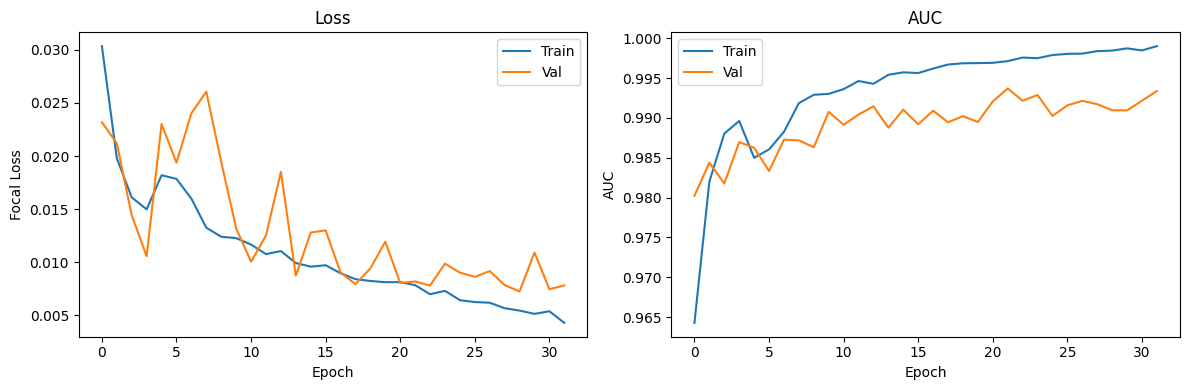

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Focal Loss'); ax1.legend(); ax1.set_title('Loss')

ax2.plot(history['train_auc'], label='Train')
ax2.plot(history['val_auc'],   label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC'); ax2.legend(); ax2.set_title('AUC')

plt.tight_layout()
plt.show()

## 9. Evaluation — Validation Set

In [14]:
# Load best checkpoint
model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))
model.eval()


def get_predictions(loader):
    all_probs, all_targets = [], []
    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(DEVICE)
            probs = torch.sigmoid(model(imgs).squeeze(1)).cpu().numpy()
            all_probs.extend(probs)
            all_targets.extend(targets.numpy())
    return np.array(all_probs), np.array(all_targets)


val_probs, val_targets = get_predictions(val_loader)

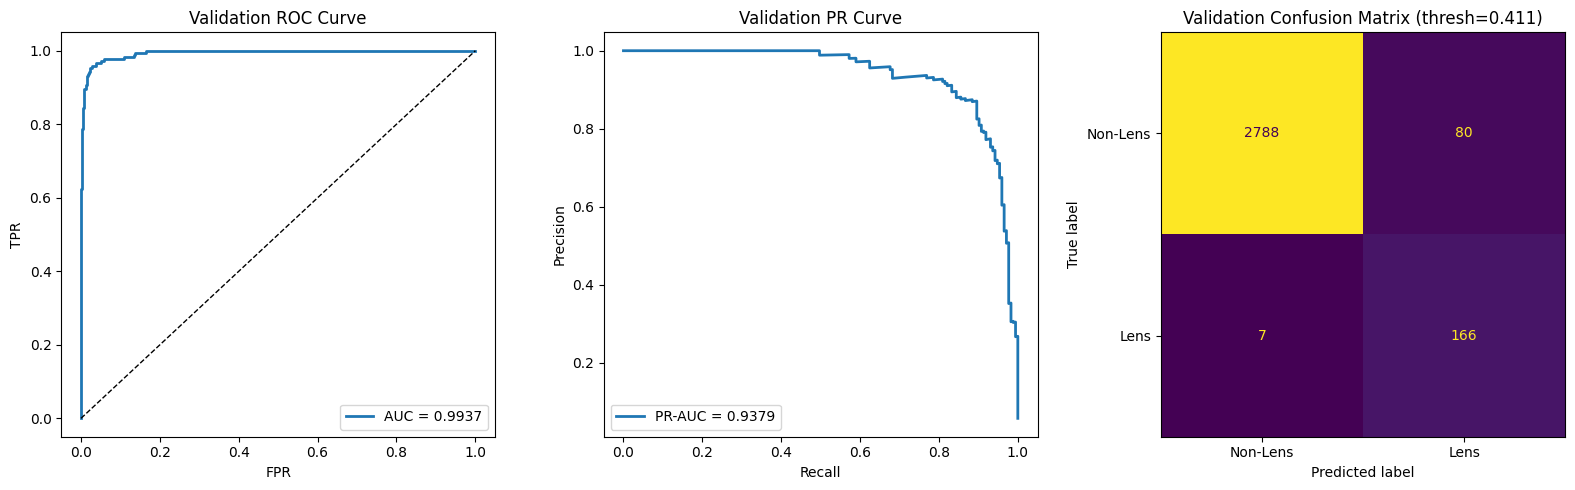

Validation — AUC: 0.9937 | PR-AUC: 0.9379 | Threshold: 0.411


In [15]:
def plot_evaluation(probs, targets, title_prefix=''):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ROC curve
    fpr, tpr, thresholds = roc_curve(targets, probs)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title(f'{title_prefix} ROC Curve'); axes[0].legend()

    # Optimal threshold via Youden index
    j_scores = tpr - fpr
    best_thresh = thresholds[np.argmax(j_scores)]

    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(targets, probs)
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision, lw=2, label=f'PR-AUC = {pr_auc:.4f}')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title(f'{title_prefix} PR Curve'); axes[1].legend()

    # Confusion matrix at optimal threshold
    preds = (probs >= best_thresh).astype(int)
    cm = confusion_matrix(targets, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Non-Lens', 'Lens']).plot(ax=axes[2], colorbar=False)
    axes[2].set_title(f'{title_prefix} Confusion Matrix (thresh={best_thresh:.3f})')

    plt.tight_layout()
    plt.show()
    print(f'{title_prefix} — AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f} | Threshold: {best_thresh:.3f}')
    return roc_auc, best_thresh


val_auc_final, val_thresh = plot_evaluation(val_probs, val_targets, title_prefix='Validation')

## 10. Evaluation — Test Set

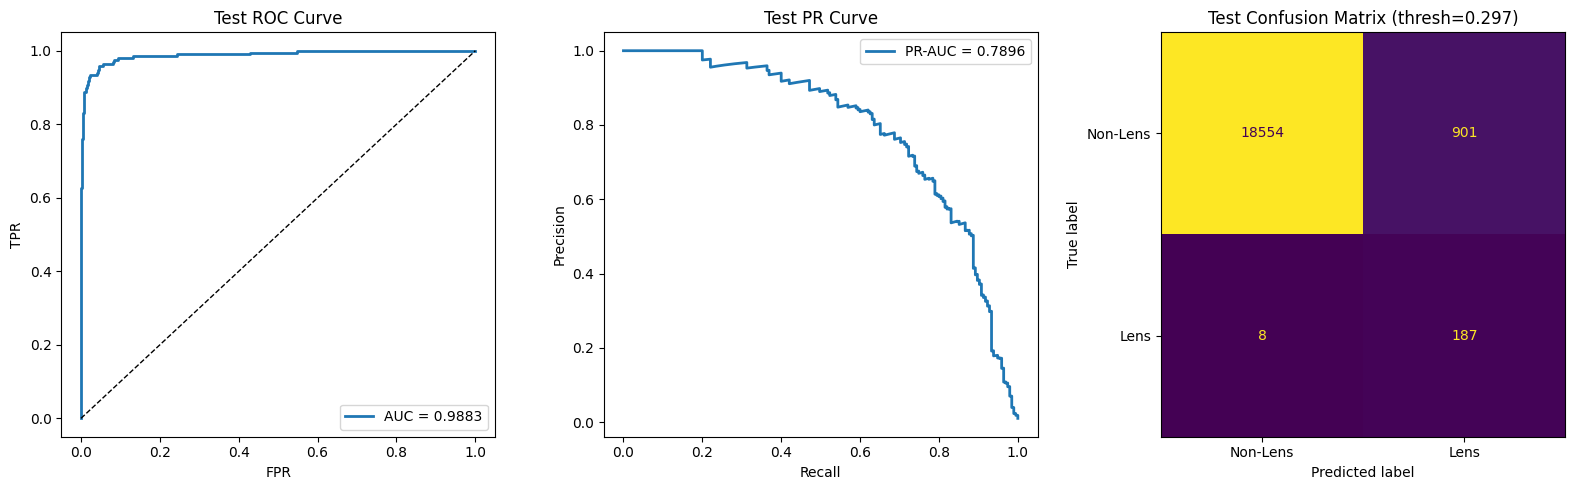

Test — AUC: 0.9883 | PR-AUC: 0.7896 | Threshold: 0.297


In [16]:
test_probs, test_targets = get_predictions(test_loader)
test_auc_final, test_thresh = plot_evaluation(test_probs, test_targets, title_prefix='Test')

In [17]:
print('\n=== Final Results ===')
print(f'Validation AUC : {val_auc_final:.4f}')
print(f'Test       AUC : {test_auc_final:.4f}')


=== Final Results ===
Validation AUC : 0.9937
Test       AUC : 0.9883


## 11. Discussion

**Why ResNet18:** The 64×64 input and small positive-class size (1,730) don't justify deeper models. ResNet18 with ImageNet pretraining converges faster and avoids overfitting on lenses.

**Why Focal Loss over weighted BCE:** The test-set skew is 1:100. A fixed class weight in BCE doesn't adapt to prediction confidence — Focal Loss dynamically suppresses the gradient from easy non-lenses the model already classifies confidently, pushing capacity toward the hard lens examples.

**Why WeightedRandomSampler alongside Focal Loss:** The sampler ensures the model sees enough lenses per batch to learn useful features early in training. Without it, the first few epochs are dominated by non-lens gradients even with Focal Loss.

**Augmentation choices:** Full 360° rotation is the most impactful — Einstein rings are rotationally symmetric and can appear at any angle in the sky. I avoided cropping because the ring structure extends close to the image boundary at 64×64.

**Threshold selection:** I used the Youden index (argmax(TPR − FPR)) on the validation ROC curve. For a search pipeline where false negatives (missed lenses) are costly, one could shift this threshold lower to boost recall at the cost of precision.

**Potential improvements:**
- Test-time augmentation (TTA) averaging predictions over rotated/flipped copies
- EfficientNet-B0 as a comparison baseline
- Self-supervised pretraining on the non-lens data before fine-tuning